In [6]:
import warnings
warnings.filterwarnings("ignore")

import torch
import numpy as np
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from sklearn.preprocessing import label_binarize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from gensim.models import Word2Vec

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [7]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/deviprasaadreddy/x-dataset/Twitter_Data.csv
/kaggle/input/datasets/deviprasaadreddy/x-dataset/Reddit_Data.csv


In [8]:
# Load correctly (DO NOT swap)
twitter_df = pd.read_csv("/kaggle/input/datasets/deviprasaadreddy/x-dataset/Twitter_Data.csv")
reddit_df = pd.read_csv("/kaggle/input/datasets/deviprasaadreddy/x-dataset/Reddit_Data.csv")

# Check columns first
print("Twitter Columns:", twitter_df.columns)
print("Reddit Columns:", reddit_df.columns)

# Rename correctly
twitter_df = twitter_df.rename(columns={
    "clean_text": "text",
    "category": "label"
})

reddit_df = reddit_df.rename(columns={
    "clean_comment": "text",
    "category": "label"
})

# Select only needed columns
twitter_df = twitter_df[["text", "label"]]
reddit_df = reddit_df[["text", "label"]]

# Merge
df = pd.concat([twitter_df, reddit_df], ignore_index=True)

df.dropna(inplace=True)

print("Final Columns:", df.columns)
print("Dataset Shape:", df.shape)

Twitter Columns: Index(['clean_text', 'category'], dtype='object')
Reddit Columns: Index(['clean_comment', 'category'], dtype='object')
Final Columns: Index(['text', 'label'], dtype='object')
Dataset Shape: (200118, 2)


In [9]:
label_map = {-1:0, 0:1, 1:2}
df['bert_label'] = df['label'].map(label_map)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'],
    df['bert_label'],
    test_size=0.2,
    stratify=df['bert_label'],
    random_state=42
)

In [10]:
ml_results = []

bow = CountVectorizer(max_features=10000)
X_train_bow = bow.fit_transform(train_texts)
X_test_bow = bow.transform(test_texts)

ml_models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SGD Classifier": SGDClassifier(loss="log_loss")
}

for name, model in ml_models.items():
    start = time.time()
    model.fit(X_train_bow, train_labels)
    preds = model.predict(X_test_bow)
    end = time.time()

    ml_results.append({
        "Model": name,
        "Accuracy": accuracy_score(test_labels, preds),
        "Precision": precision_score(test_labels, preds, average="weighted"),
        "Recall": recall_score(test_labels, preds, average="weighted"),
        "F1": f1_score(test_labels, preds, average="weighted"),
        "Training Time": round(end-start,2)
    })

print(pd.DataFrame(ml_results))

                 Model  Accuracy  Precision    Recall        F1  Training Time
0          Naive Bayes  0.795348   0.799398  0.795348  0.795185           0.04
1  Logistic Regression  0.949205   0.948979  0.949205  0.949058          41.32
2           Linear SVM  0.952828   0.952726  0.952828  0.952771         114.20
3        Random Forest  0.851864   0.857643  0.851864  0.845385        1256.22
4       SGD Classifier  0.904557   0.906564  0.904557  0.903073           1.12


In [11]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [12]:
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
test_dataset = SentimentDataset(test_encodings, test_labels)

In [13]:
full_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

def model_summary(model, name):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{name}")
    print("Total Parameters:", total)
    print("Trainable Parameters:", trainable)
    print("Non-Trainable:", total - trainable)

model_summary(full_model, "FULL BERT (12 Layers)")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



FULL BERT (12 Layers)
Total Parameters: 109484547
Trainable Parameters: 109484547
Non-Trainable: 0


In [14]:
reduced_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
)

# Reduce layers
reduced_model.bert.encoder.layer = torch.nn.ModuleList(
    reduced_model.bert.encoder.layer[:6]
)

# Freeze first 2 layers
for layer in reduced_model.bert.encoder.layer[:2]:
    for param in layer.parameters():
        param.requires_grad = False

model_summary(reduced_model, "REDUCED BERT (6 Layers, 2 Frozen)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



REDUCED BERT (6 Layers, 2 Frozen)
Total Parameters: 66957315
Trainable Parameters: 52781571
Non-Trainable: 14175744


In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
        "f1": f1_score(labels, preds, average="weighted"),
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",   # Kaggle compatible
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=reduced_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.258029,0.224653,0.964421,0.965315,0.964421,0.964675
2,0.168167,0.189768,0.973641,0.973806,0.973641,0.973562
3,0.121017,0.182000,0.977039,0.977116,0.977039,0.977000
4,0.091122,0.189645,0.978763,0.978884,0.978763,0.978805


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=20012, training_loss=0.22951631594390456, metrics={'train_runtime': 8428.4876, 'train_samples_per_second': 75.978, 'train_steps_per_second': 2.374, 'total_flos': 4.241522784275251e+16, 'train_loss': 0.22951631594390456, 'epoch': 4.0})

In [16]:
preds = trainer.predict(test_dataset)
bert_preds = np.argmax(preds.predictions, axis=1)

print("\nOVERALL METRICS")
print("Accuracy:", accuracy_score(test_labels, bert_preds))
print("Precision:", precision_score(test_labels, bert_preds, average="weighted"))
print("Recall:", recall_score(test_labels, bert_preds, average="weighted"))
print("F1 Score:", f1_score(test_labels, bert_preds, average="weighted"))


OVERALL METRICS
Accuracy: 0.9787627423545873
Precision: 0.9788838903596968
Recall: 0.9787627423545873
F1 Score: 0.9788050707193492


In [17]:
print("\nPER CLASS METRICS")
print(classification_report(
    test_labels,
    bert_preds,
    target_names=["Negative","Neutral","Positive"]
))


PER CLASS METRICS
              precision    recall  f1-score   support

    Negative       0.95      0.97      0.96      8757
     Neutral       0.99      0.98      0.99     13651
    Positive       0.98      0.98      0.98     17616

    accuracy                           0.98     40024
   macro avg       0.98      0.98      0.98     40024
weighted avg       0.98      0.98      0.98     40024



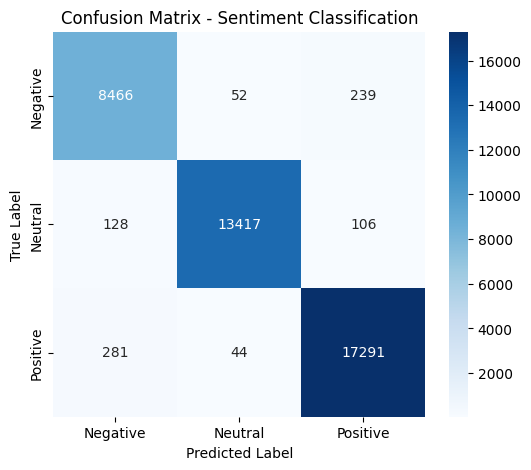

In [18]:
# Compute confusion matrix
cm = confusion_matrix(test_labels, bert_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])

plt.title("Confusion Matrix - Sentiment Classification")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

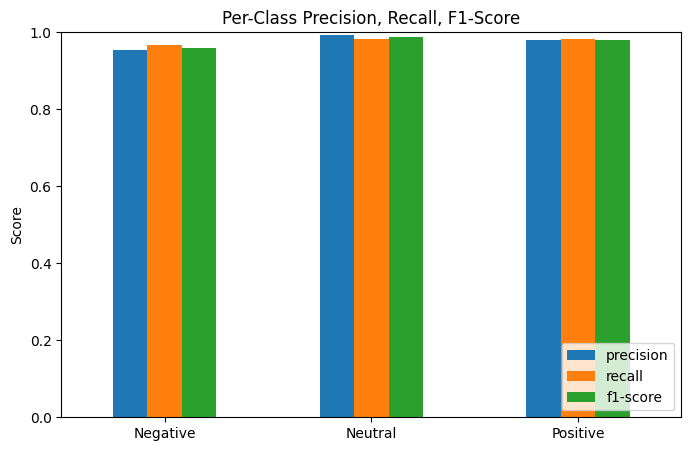

In [19]:
from sklearn.metrics import classification_report
import pandas as pd

# Get classification report as dictionary
report = classification_report(
    test_labels,
    bert_preds,
    target_names=["Negative","Neutral","Positive"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Select only class rows
class_metrics = report_df.loc[["Negative","Neutral","Positive"], 
                              ["precision","recall","f1-score"]]

# Plot
class_metrics.plot(kind="bar", figsize=(8,5))
plt.title("Per-Class Precision, Recall, F1-Score")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

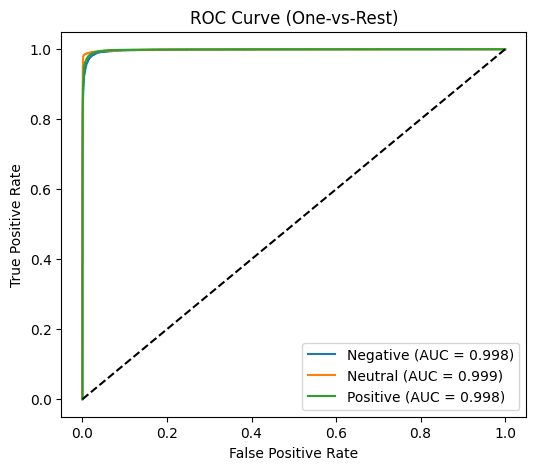

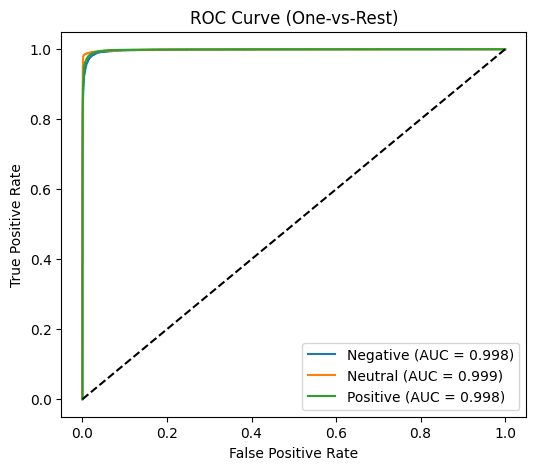

In [ ]:

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import torch

# Convert labels to binary format
y_bin = label_binarize(test_labels, classes=[0,1,2])

# Convert logits to probabilities
probs = torch.nn.functional.softmax(
    torch.tensor(preds.predictions), dim=1
).numpy()

plt.figure(figsize=(6,5))

for i, label in enumerate(["Negative","Neutral","Positive"]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
# Convert labels to binary format
y_bin = label_binarize(test_labels, classes=[0,1,2])

# Convert logits to probabilities
probs = torch.nn.functional.softmax(
    torch.tensor(preds.predictions), dim=1
).numpy()

plt.figure(figsize=(6,5))

for i, label in enumerate(["Negative","Neutral","Positive"]):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

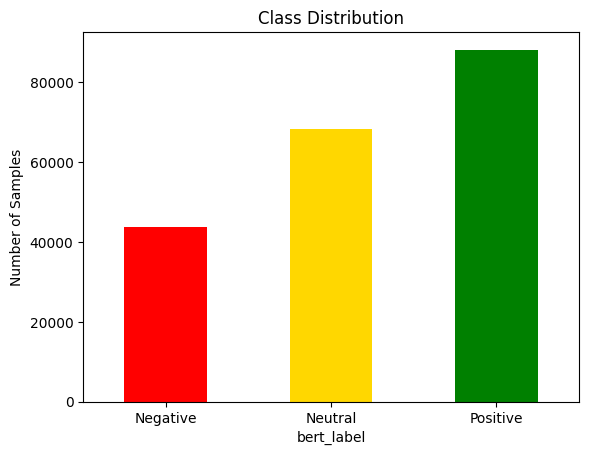

In [ ]:
import matplotlib.pyplot as plt

df["bert_label"].value_counts().sort_index().plot(
    kind="bar",
    color=["red","gold","green"]
)

plt.xticks([0,1,2], ["Negative","Neutral","Positive"], rotation=0)
plt.title("Class Distribution")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
reduced_model.config.output_hidden_states = True
reduced_model.to(device)

sample = test_dataset[0]
sample = {k: v.unsqueeze(0).to(device) for k,v in sample.items()}

outputs = reduced_model(**sample)

hidden_states = outputs.hidden_states

print("\nNumber of Transformer Layers:", len(hidden_states))

for i, layer in enumerate(hidden_states):
    print(f"Layer {i} shape:", layer.shape)


Number of Transformer Layers: 7
Layer 0 shape: torch.Size([1, 256, 768])
Layer 1 shape: torch.Size([1, 256, 768])
Layer 2 shape: torch.Size([1, 256, 768])
Layer 3 shape: torch.Size([1, 256, 768])
Layer 4 shape: torch.Size([1, 256, 768])
Layer 5 shape: torch.Size([1, 256, 768])
Layer 6 shape: torch.Size([1, 256, 768])


In [ ]:
import pandas as pd

summary_data = []

for name, model in [
    ("Full BERT", full_model),
    ("Reduced BERT", reduced_model)
]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    summary_data.append({
        "Model": name,
        "Total Params": total,
        "Trainable Params": trainable,
        "Non-Trainable Params": total - trainable
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df)

          Model  Total Params  Trainable Params  Non-Trainable Params
0     Full BERT     109484547         109484547                     0
1  Reduced BERT      66957315          52781571              14175744


In [ ]:
print("\n===== PARAMETER NAMES IN EACH MODEL =====\n")

for name, model in [
    ("Full BERT", full_model),
    ("Reduced BERT", reduced_model)
]:
    print(f"\n--- {name} ---\n")
    
    for param_name, param in model.named_parameters():
        print(f"{param_name} → Shape: {param.shape}")


===== PARAMETER NAMES IN EACH MODEL =====


--- Full BERT ---

bert.embeddings.word_embeddings.weight → Shape: torch.Size([30522, 768])
bert.embeddings.position_embeddings.weight → Shape: torch.Size([512, 768])
bert.embeddings.token_type_embeddings.weight → Shape: torch.Size([2, 768])
bert.embeddings.LayerNorm.weight → Shape: torch.Size([768])
bert.embeddings.LayerNorm.bias → Shape: torch.Size([768])
bert.encoder.layer.0.attention.self.query.weight → Shape: torch.Size([768, 768])
bert.encoder.layer.0.attention.self.query.bias → Shape: torch.Size([768])
bert.encoder.layer.0.attention.self.key.weight → Shape: torch.Size([768, 768])
bert.encoder.layer.0.attention.self.key.bias → Shape: torch.Size([768])
bert.encoder.layer.0.attention.self.value.weight → Shape: torch.Size([768, 768])
bert.encoder.layer.0.attention.self.value.bias → Shape: torch.Size([768])
bert.encoder.layer.0.attention.output.dense.weight → Shape: torch.Size([768, 768])
bert.encoder.layer.0.attention.output.dense.bias → 

In [ ]:
# Get parameter names from full model
full_param_names = set(name for name, _ in full_model.named_parameters())

# Get parameter names from reduced model
reduced_param_names = set(name for name, _ in reduced_model.named_parameters())

In [ ]:
# Parameters removed entirely
removed_params = full_param_names - reduced_param_names

print("\n===== PARAMETERS REMOVED COMPLETELY =====\n")

for name in sorted(removed_params):
    print(name)


===== PARAMETERS REMOVED COMPLETELY =====

bert.encoder.layer.10.attention.output.LayerNorm.bias
bert.encoder.layer.10.attention.output.LayerNorm.weight
bert.encoder.layer.10.attention.output.dense.bias
bert.encoder.layer.10.attention.output.dense.weight
bert.encoder.layer.10.attention.self.key.bias
bert.encoder.layer.10.attention.self.key.weight
bert.encoder.layer.10.attention.self.query.bias
bert.encoder.layer.10.attention.self.query.weight
bert.encoder.layer.10.attention.self.value.bias
bert.encoder.layer.10.attention.self.value.weight
bert.encoder.layer.10.intermediate.dense.bias
bert.encoder.layer.10.intermediate.dense.weight
bert.encoder.layer.10.output.LayerNorm.bias
bert.encoder.layer.10.output.LayerNorm.weight
bert.encoder.layer.10.output.dense.bias
bert.encoder.layer.10.output.dense.weight
bert.encoder.layer.11.attention.output.LayerNorm.bias
bert.encoder.layer.11.attention.output.LayerNorm.weight
bert.encoder.layer.11.attention.output.dense.bias
bert.encoder.layer.11.attent

In [ ]:
# Select layers to print
layers_to_print = [1, 2]   # Encoder Layer 1 and Encoder Layer 6

print("\n===== SELECTED LAYER FEATURE VECTORS =====")

for i in layers_to_print:
    cls_vector = hidden_states[i][0, 0, :]   # CLS token
    print(f"\nLayer {i} CLS Vector Shape:", cls_vector.shape)
    print(cls_vector.detach().cpu().numpy())


===== SELECTED LAYER FEATURE VECTORS =====

Layer 1 CLS Vector Shape: torch.Size([768])
[ 2.16550395e-01  3.00932657e-02 -6.36154339e-02 -2.18886614e-01
  1.59041584e-01  6.79469900e-03 -1.44616917e-01 -1.08302243e-01
  3.68258692e-02 -4.89347637e-01  6.25459030e-02  5.10047860e-02
  7.55861998e-02 -1.48052797e-01 -2.82370061e-01  3.36829394e-01
  3.15926850e-01  2.10201159e-01 -8.79418254e-02 -4.98997957e-01
 -5.59458196e-01 -3.37855130e-01 -1.45375311e-01 -1.02489792e-01
 -5.39072528e-02 -3.05581540e-01 -1.86045066e-01  1.36340797e-01
 -3.20415497e-02 -2.82301493e-02 -2.63654053e-01 -1.06608391e-01
  2.26621613e-01  8.94831270e-02 -3.41926217e-01  1.30440846e-01
 -2.33494014e-01  1.61064744e-01  6.35702861e-03  1.17643118e-01
  2.32996121e-01 -2.26415306e-01  4.13246453e-02  2.44456977e-01
 -1.03959339e-02  1.73007771e-01 -2.12491035e+00 -4.42305468e-02
  5.23705840e-01 -2.24603415e-01  5.59676230e-01  9.92104709e-02
 -3.87588620e-01  7.32600510e-01  2.13720873e-01 -1.24603905e-01
 